# Exploratory Data Analysis (EDA) & Feature Engineering

## 1. Class Distribution Analysis
To understand the dataset's label distribution across the five target pathologies (**Atelectasis**, **Effusion**, **Infiltration**, **Nodule**, and **Pneumothorax**), we visualised the count of negative (`-ve`) and positive (`+ve`) labels.

- **Observation:** Significant class imbalance is present across all pathologies. Negative instances (`-ve`) vastly outnumber positive diagnoses (`+ve`).
- **Action / Implication:** Standard accuracy metrics will be misleading. Model training will require loss weighting (e.g., Weighted Cross-Entropy, Focal Loss) or dynamic sampling strategies to handle the class imbalance effectively.

---

## 2. Multi-Label Sample Mapping
We analysed a subset of 13 image samples to inspect individual image-to-label distributions and check for co-occurrence / multi-label patterns across conditions.

- **Observation:** Certain samples present multiple positive labels simultaneously (e.g., co-occurrence of Effusion and Infiltration), confirming the multi-label nature of chest X-ray diagnosis.
- **Action / Implication:** The task is framed as a multi-label binary classification problem rather than a standard single-label multiclass problem. Binary Cross-Entropy (BCE) loss per condition will be used during model training.

---

## 3. Sample Visualisation & Preprocessing Validation
Representative chest X-ray images for each pathology were rendered and inspected to verify image pipeline integrity, dimensions, and visual clarity.

- **Observation:** Standard radiographic variations exist across samples (differing contrast, orientation tags, portable vs. standard position).
- **Preprocessing Pipeline:**
  - Standardised image resizing (e.g., 224x224 or 512x512 depending on model architecture).
  - Intensity normalization (zero-mean unit-variance scaling).
  - Data augmentation (subtle rotation, horizontal flip, brightness adjustment) to prevent overfitting.

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

In [2]:
df = pd.read_csv("train_labels.csv")
condition_cols = df.columns[1:]
print(df.head())
print(condition_cols)

        Image Index  Atelectasis  Effusion  Infiltration  Nodule  Pneumothorax
0  00000013_005.png            0         0             1       0             1
1  00000013_026.png            0         0             0       0             0
2  00000017_001.png            0         0             0       0             0
3  00000042_002.png            0         0             0       0             0
4  00000057_001.png            0         0             0       0             0
Index(['Atelectasis', 'Effusion', 'Infiltration', 'Nodule', 'Pneumothorax'], dtype='str')


In [3]:
df['conditions'] = df[condition_cols].sum(axis=1)

df['category'] = df['conditions'].apply(
    lambda x: 'Zero' if x == 0 else 'One' if x == 1 else 'Multiple'
)
df.drop('conditions',axis=1, inplace=True)
df.head()

,Image Index,Atelectasis,Effusion,Infiltration,Nodule,Pneumothorax,category
0,00000013_005.png,0,0,1,0,1,Multiple
1,00000013_026.png,0,0,0,0,0,Zero
2,00000017_001.png,0,0,0,0,0,Zero
3,00000042_002.png,0,0,0,0,0,Zero
4,00000057_001.png,0,0,0,0,0,Zero


Atelectasis
0    4078
1     406
Name: count, dtype: int64

Effusion
0    3969
1     515
Name: count, dtype: int64

Infiltration
0    3711
1     773
Name: count, dtype: int64

Nodule
0    4234
1     250
Name: count, dtype: int64

Pneumothorax
0    4267
1     217
Name: count, dtype: int64



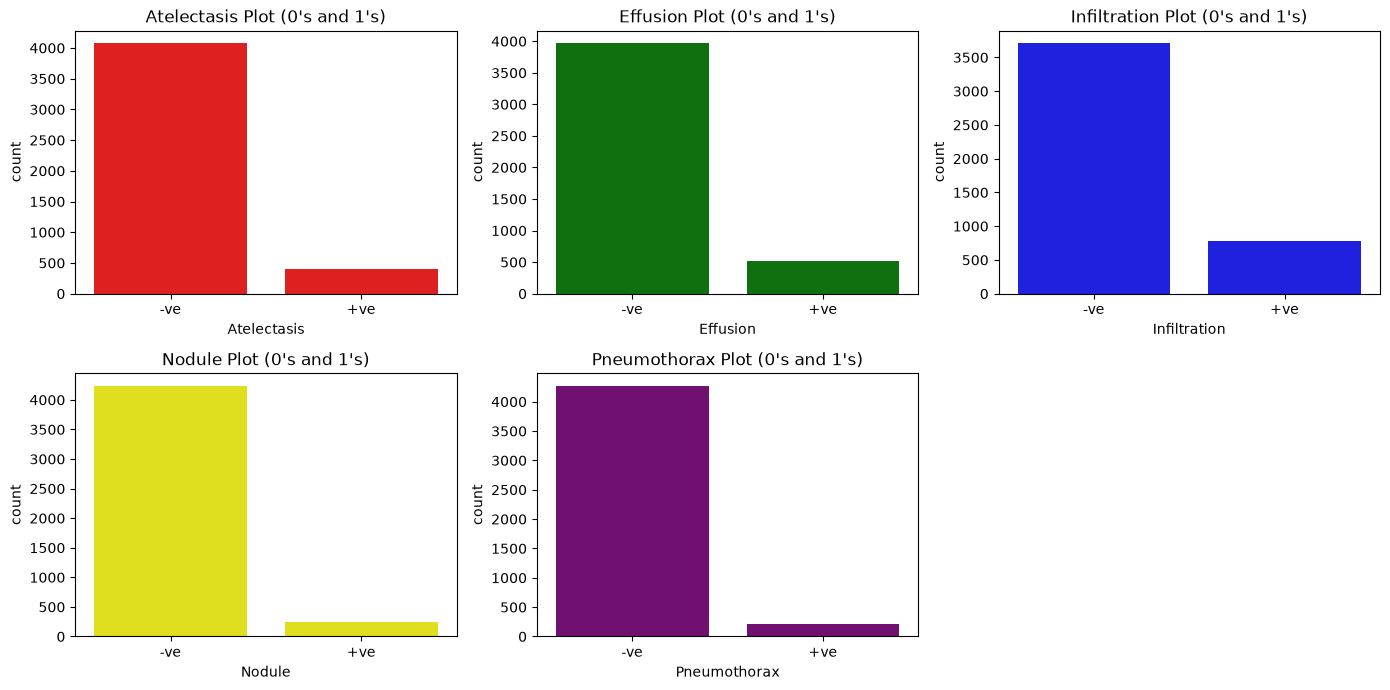

In [4]:
#Count plot to count the positives vs negatives for each of the 5 conditions.
#Heavy class imbalance across all 5 conditions is clearly shown.

#CountPlot is specifically used to represet a count of data. Only x or y axis col name is req.
conditions = ['Atelectasis', 'Effusion', 'Infiltration', 'Nodule', 'Pneumothorax']
colours = ['r', 'g', 'b', 'yellow', 'purple']
label = {0:'-ve', 1:'+ve'}

plt.figure(figsize=(14,10))
for i in range(len(conditions)):
    print(f"{df[conditions[i]].value_counts()}\n")
    plt.subplot(3,3,i+1)
    plt.title(f"{conditions[i]} Plot (0's and 1's)")
    sns.countplot(data=df, x=df[conditions[i]].map(label), color=colours[i], order=['-ve', '+ve'])
    plt.tight_layout()

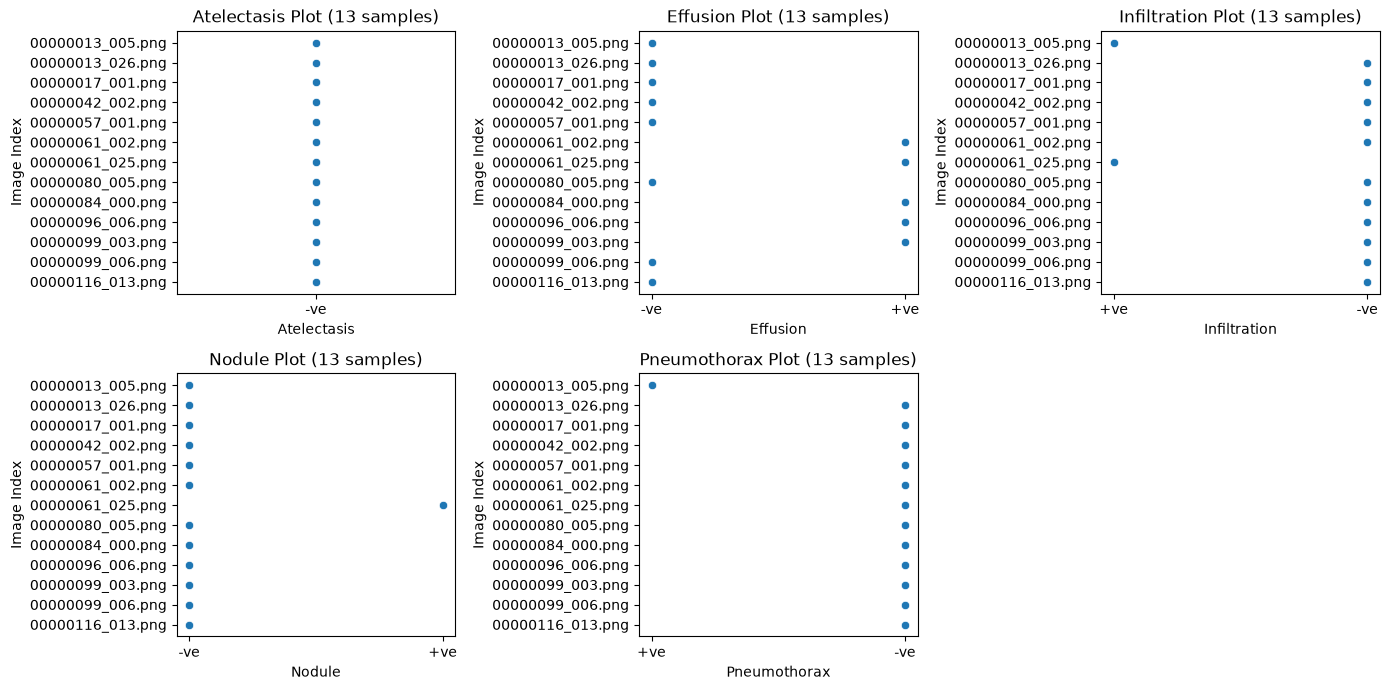

In [5]:
#Scatter plot for the images that have the respective condition
samples = df['Image Index'][:13]

plt.figure(figsize=(14,10))
for i in range(len(conditions)):
    plt.subplot(3,3,i+1)
    plt.title(f"{conditions[i]} Plot (13 samples)")
    sns.scatterplot(data=df, x=df[conditions[i]].map(label), y=samples)
    #plt.xlim(['-ve', '+ve'])
    plt.tight_layout()

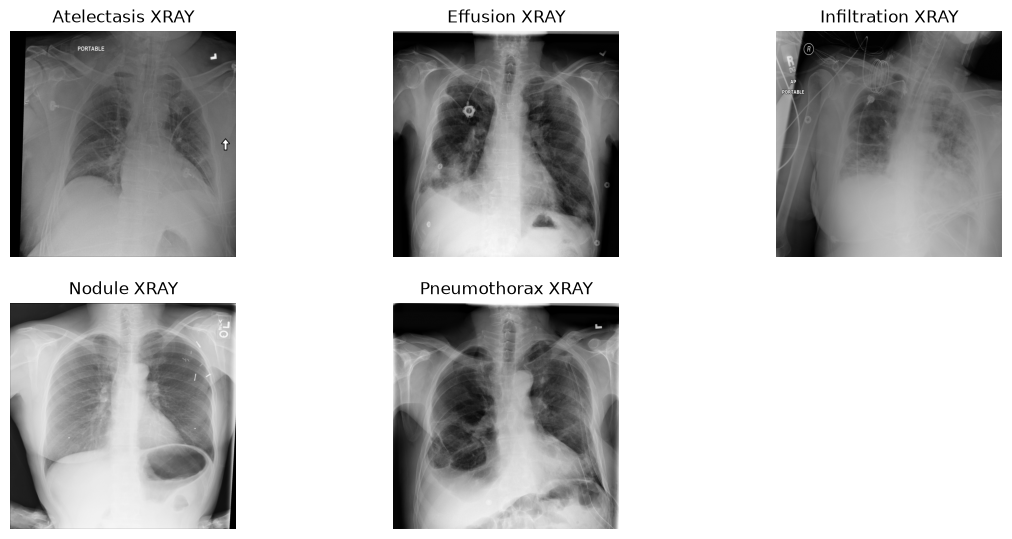

In [6]:
#Displaying the actual image thumbnails per condition
plt.figure(figsize=(14,10))

file_paths = ['xray_images/Atelectasis_xray.png', 'xray_images/Effusion_xray.png', 'xray_images/Infiltration_xray.png', 'xray_images/Nodule_xray.png', 'xray_images/Pneumothorax_xray.png']
for i in range(len(file_paths)):
    img = mpimg.imread(file_paths[i])
    plt.subplot(3,3,i+1)
    plt.imshow(img, cmap = 'gray')
    plt.title(f"{conditions[i]} XRAY")
    plt.axis('off')

plt.show()